# 1. Introdução

## 1.1. Contexto do problema

## 1.2. Objetivo geral

## 1.3. Objetivos específicos

## 1.4. Breve configuração do ambiente

Antes de começar, peço que aguardem a instalação das dependências do projeto.

Após a instalação, será necessário reiniciar o embiente de execução.

Pede-se apenas que se clique novamente em "Executar tudo" após o término da instalação.

In [49]:
%%capture

!wget -nc 'https://github.com/ffserro/analise-de-dados-boas-praticas/raw/refs/heads/main/pyproject.toml'
!pip install -e .

In [50]:
from warnings import filterwarnings
filterwarnings('ignore')

# 2. Base de Dados

A base de dados será carregada com a biblioteca Polars.

O motivo dessa escolha foi que esta biblioteca seria mais rápida do que o Pandas quando tratamos de DataFrames com mais de 1e6 linhas. Acontece que durante a limpeza o conjunto dos dados acabou ficando menor do que isso, mas como eu gostei de aprender sobre a biblioteca e achei a escrita bem mais elegante e mais fácil de vetorizar grandes transformações em comparação com o Pandas, decidi manter o uso predominante do Polars.

In [51]:
import polars as pl

df = (
    pl.read_parquet([f'https://github.com/ffserro/analise-de-dados-boas-praticas/raw/refs/heads/main/database_2/metadata_part_{i:04d}.parquet' for i in range(1, 6)])
    .join(
        pl.read_parquet([f'https://github.com/ffserro/analise-de-dados-boas-praticas/raw/refs/heads/main/database_2/textos_part_{i:04d}.parquet' for i in range(1, 24)]),
        on='id'
    )
    .with_columns(
        pl.col('pubDate').str.to_date(),
        pl.col('pubName').str.head(3),  # Já com uma primeira limpeza porque existem algumas edições especiais que  tem um 'E' no final, como DO1E, por exemplo
    )
    .filter(
        pl.col('artCategory').str.to_lowercase().str.starts_with('ministério da defesa'),
        pl.col('artCategory').str.to_lowercase().str.contains(r'marinha|ex[ée]rcito|aeron[áa]utica')    # Como a proposta é fazer uma análise entre as três forças, não nos interessam os órgãos que não sejam subordinados ao Ministério da Defesa, nem as publicações do próprio Ministério.
    )
)

df.tail()

numberPage,pubName,name,artType,pubDate,artCategory,pdfPage,editionNumber,id,identifica,data,ementa,titulo,subtitulo,autores,idOficio,artClass,artSection,artSize,artNotes,highlightType,highlightPriority,highlight,idMateria,highlightimage,highlightimagename,texto
str,str,str,str,date,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""58""","""DO3""","""2025-12-30/11503645/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23469728""","""EXTRATO DE CREDENCIAMENTO Nº 3…",null,null,null,null,null,"""11503645""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23469728""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 3…"
"""58""","""DO3""","""2025-12-30/11503746/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23470217""","""EXTRATO DE CREDENCIAMENTO Nº 3…",null,null,null,null,null,"""11503746""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23470217""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 3…"
"""58""","""DO3""","""2025-12-30/11503765/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23470438""","""EXTRATO DE CREDENCIAMENTO Nº 2…",null,null,null,null,null,"""11503765""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23470438""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 2…"
"""58""","""DO3""","""2025-12-30/11503761/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23470552""","""EXTRATO DE CREDENCIAMENTO Nº 3…",null,null,null,null,null,"""11503761""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23470552""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 3…"
"""58""","""DO3""","""2025-12-30/11503780/COMPRASNET…","""Extrato de Credenciamento""",2025-12-31,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""249""","""530_20251231_23470580""","""EXTRATO DE CREDENCIAMENTO Nº 3…",null,null,null,null,null,"""11503780""","""00016:00012:00008:00042:00016:…",null,"""12""","""""","""""","""""","""""","""23470580""","""""","""""","""EXTRATO DE CREDENCIAMENTO Nº 3…"


In [52]:
df.shape

(1087705, 27)

## 2.1. Origem dos dados

Todos os dados utilizados foram extraídos da [Base de Dados de Publicações do DOU](https://in.gov.br/acesso-a-informacao/dados-abertos/base-de-dados).

O dicionário de dados ainda não foi disponibilizado segundo o próprio site, porém há uma breve explicação sobre a divisão dos documentos entre Seções.

Os documentos referentes às publicações estão no formato .xml, compactados em um arquivo .zip por ano, mês e seção.

## 2.2. Etapas de coleta

Toda a coleta foi realizada com um crawler básico, que está no repositório neste [link](https://github.com/ffserro/analise-de-dados-boas-praticas/blob/main/data_fetcher/pack_downloader.py).

Ele busca os links no site dos dados abertos do DOU, enviando um request com ano e mês. Precisa ser feito dessa forma, porque os links são gerados por seção, e se não contiverem informações dos cookies, tentar baixar os arquivos retorna um bad request.

Depois de resgatados os links, imediatamente se inicia o download do arquivo .zip em bytes para uma pasta local, onde é descompactado.

Após descompactar, eu fiz uma primeira filtragem para deletar todos os arquivos que não possuíssem em seu texto o termo "Ministério da Defesa".

A pasta com os arquivos baixados não pode ser armazenada no repositório porque possuía uma grande quantidade de arquivos, além do limite permitido pelo github. A solução foi já construir um dataset preliminar, no formato .parquet por ser mais leve, e salvá-lo particionado para que o git lfs permitisse o upload para o repositório. Essa etapa foi realizada por este [script](https://github.com/ffserro/analise-de-dados-boas-praticas/blob/main/bd_utils/bd_builder.py).

Durante a etapa de transformar os arquivos .xml em um dataframe, foram extraídas as informações tag por tag usando regex puro. Assim é a estrutura padrão de um arquivo:
```
<xml>
    <article id="" name="" idOficio="" pubName="" artType="" pubDate="" artClass="" artCategory="" artSize="" artNotes="" numberPage="" pdfPage="" editionNumber="" highlightType="" highlightPriority="" highlight="" highlightimage="" highlightimagename="" idMateria="">
        <body>
            <Identifica> </Identifica>
            <Data> </Data>
            <Ementa> </Ementa>
            <Titulo> </Titulo>
            <SubTitulo> </SubTitulo>
            <Texto> </Texto>
            <Autores>
                <assina> </assina>
                <cargo> </cargo>
            </Autores>
        </body>
        <Midias> </Midias>
    </article>
</xml>
```
Desta estrutura foram extraídos tanto os atributos da tag `article` quanto o conteúdo textual das tags `Identifica`, `Data`, `Ementa`, `Titulo`, `SubTitulo`, `Texto`, `Autores` e transformados em colunas deste dataframe.

## 2.3. Período analisado

São disponibilizados pela Base de Dados Abertos do DOU as publicações desde o ano de 2002 até o ano de 2026.

In [53]:
from plotly import express as px
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt

fig = px.area(
    (
      df
      .group_by(pl.col('pubDate').dt.strftime('%Y/%m'), pl.col('pubName').str.head(3))
      .agg(pl.len())
      .sort('pubDate', 'pubName')
      .to_pandas()
    ),
    x='pubDate',
    y='len',
    color='pubName',
    title='Volume de artigos por mês e seção',
    labels={'len':'Volume', 'pubDate':'Mês de referência', 'pubName':'Seção'},
)
fig.show()

# plt.figure(figsize=(20,8))

# (
#     so.Plot(volume_por_ano.to_pandas(), 'pubDate', 'len', color='pubName').add(so.Area(alpha=.7), so.Stack())
# )

In [54]:
del fig

Pode ser observado uma quantidade de dados faltosos durante todo o ano de 2017.

Provavelmente a própria plataforma do DOU estava sendo reformulada durante esse período, porque se observam dados muito mais estruturados e consistentes a partir do ano de 2018.

Como exemplo mostro abaixo uma das colunas do dataframe que exemplifica essa melhor estruturação:

In [55]:
pl.concat(
    [
        df.filter(pl.col('pubDate').dt.year() < 2018).select(pl.col('artType').unique().alias('type_antes')),
        df.filter(pl.col('pubDate').dt.year() >= 2018).select(pl.col('artType').unique().alias('type_depois')),
    ],
    how='horizontal'
).drop_nulls().show(limit=20, fmt_str_lengths=50)

type_antes,type_depois
str,str
"""PORTARIAS-SIP/10,""","""Aviso de Penalidade"""
"""ME""","""Extrato de Reconhecimento de Dívida"""
"""APÊNDICE""","""Extrato de Concessão de Auxilio à Pesquisa"""
"""EDITAIS""","""Aviso de Pré-Qualificação"""
"""RETIFICACÃO""","""Extrato de Carta-contrato"""
"""ITOMADA""","""Edital de Vestibular"""
"""PRÉ-QUALIFICAÇÃO""","""Ato"""
"""MATRÍCULA""","""Extrato de Rescisão"""
"""Termo""","""Extrato de Dispensa de Licitação"""


Desta forma, por simplicidade e para limitar o escopo, vou considerar apenas os dados a partir do ano de 2018.

In [56]:
df = (
    df
    .filter(pl.col('pubDate').dt.year() >= 2018)
)

(
    df
    .select(
        pl.col('pubDate').min().alias('de'),
        pl.col('pubDate').max().alias('ate')
    )
)

de,ate
date,date
2018-03-07,2026-02-27


## 2.4. Limpeza e limitações

### 2.4.1. Valores nulos

Inicio a limpeza dos dados verificando a quantidade de valores nulos que cada uma das colunas contém, expressa aqui como razão entre a quantidade de nulos e o total de observações no conjunto de dados.

In [57]:
df.select(
    (pl.all().null_count() / pl.len() * 100).round(2).name.suffix("_null_pct")
).transpose(include_header=True).sort(by='column_0', descending=True).show(limit=15)

column,column_0
str,f64
"""titulo_null_pct""",100.0
"""autores_null_pct""",100.0
"""artSection_null_pct""",100.0
"""subtitulo_null_pct""",99.92
"""ementa_null_pct""",99.27
"""data_null_pct""",97.27
"""highlightimage_null_pct""",16.69
"""highlightimagename_null_pct""",16.69
"""highlightType_null_pct""",1.92


As colunas `titulo`, `autores`, `artSection`, `subtitulo`, `ementa` e `data`, embora pudessem conter dados muito úteis para análise, possuem uma quantidade insignificante de dados presentes, não podendo então serem consideradas. Removerei estas colunas do dataframe.

In [58]:
df = df.drop('titulo', 'autores', 'artSection', 'subtitulo', 'ementa', 'data')

### 2.4.2. Valores únicos

A próxima verificação é a quantidade de valores únicos por coluna. Algumas colunas naturalmente são compostas na sua totalidade por valores nulos, como é o exemplo do `id`, que identifica uma observação. No entanto, para uma análise dos dados, com exceção da coluna que seria a chave primária (`id`), ter outras colunas com dados únicos não permite extrair muita informação, já que não fornece um padrão de semelhança ou agrupamento das observações.

In [59]:
df.select(
    (pl.all().n_unique() / pl.len() * 100).round(2).name.suffix('_unique_pct')
).transpose(include_header=True).sort(by='column_0', descending=True).show(limit=15)

column,column_0
str,f64
"""id_unique_pct""",100.0
"""idMateria_unique_pct""",99.1
"""texto_unique_pct""",98.77
"""name_unique_pct""",81.69
"""idOficio_unique_pct""",65.17
"""identifica_unique_pct""",48.87
"""artClass_unique_pct""",32.65
"""pdfPage_unique_pct""",9.72
"""pubDate_unique_pct""",0.39


No primeiro momento notei que `idMateria`, que me parece que deveria ter 100% de valores únicos, se repete algumas vezes. Por quê?

In [60]:
df.filter(pl.col('idMateria').is_duplicated() & ~pl.col('idMateria').is_null()).sort(by=['idMateria', 'numberPage'], descending=[True, False]).select('idMateria', 'numberPage', 'texto')

idMateria,numberPage,texto
str,str,str
"""23616869""","""15""","""ATA DA ASSEMBLÉIA GERAL EXTRAO…"
"""23616869""","""18""","""Seção VII Competências do Pres…"
"""23591548""","""18""","""PORTARIA DIRENS/DCR Nº 1.018, …"
"""23591548""","""21""","""Art.98 O candidato menor de id…"
"""23591548""","""24""","""CAPÍTULO VI RECURSOS Art. 218 …"
…,…,…
"""10632282""","""27""","""CAPÍTULO VIII DO EXAME DE HABI…"
"""10632282""","""29""","""I - realizar, no prazo previst…"
"""10632282""","""31""","""_____. Estado Maior do Exércit…"


Algumas matérias, por serem mais extensas, tiveram seu texto ocupando mais do que uma página da publicação do Diário Oficial daquela data, por isso o texto aparece partido.

Abaixo, eu restituo os fragmentos dos textos ao seu preâmbulo, unificando sob uma observação. Espera-se com isso que a coluna `idMateria` se torne uma coluna de valores únicos.

In [61]:
df = (
    df
    .select(pl.all().exclude('texto'))
    .sort(by=['idMateria', 'numberPage'], descending=[True, False])
    .unique('idMateria', keep='first')
    .join(
        (
            df
            .sort(by=['idMateria', 'numberPage'], descending=[True, False])
            .group_by('idMateria')
            .agg(pl.col('texto').str.join('\n'))
        ), on='idMateria'
    )
)

Primeiro foi criado um dataframe sem a coluna `texto` ao qual foram reintegrados os textos devidamente concatenados.

In [62]:
df.select(
    (pl.all().n_unique() / pl.len() * 100).round(2).name.suffix('_unique_pct')
).transpose(include_header=True).sort(by='column_0', descending=True).show(limit=15)

column,column_0
str,f64
"""id_unique_pct""",100.0
"""idMateria_unique_pct""",100.0
"""texto_unique_pct""",98.84
"""name_unique_pct""",81.89
"""idOficio_unique_pct""",65.73
"""identifica_unique_pct""",49.21
"""artClass_unique_pct""",32.74
"""pdfPage_unique_pct""",9.26
"""pubDate_unique_pct""",0.39


Assim, os identificadores de matéria se tornaram únicos, em mesma quantidade que os identificadores dos documentos.

In [63]:
(
    df
    .select(
        pl.col('idMateria').n_unique().alias('contagem_materias'),
        pl.col('id').n_unique().alias('contagem_documentos')
    )
)

contagem_materias,contagem_documentos
u32,u32
506666,506666


Não havendo mais necessidade de possuir dois identificadores diferentes, e como conhecer o número da página que contém a publicação não é mais útil, as duas colunas serão removidas.

In [64]:
df = (
    df.drop('idMateria', 'numberPage')
)

Agora eu quero saber porque é que os nomes dos documentos e os identificadores dos ofícios não são únicos.

In [65]:
df.sort(by=['pubDate', 'name']).filter(pl.col('name').is_duplicated()).select('name').show(limit=15, fmt_str_lengths=500)

name
str
"""##Ata"""
"""21. Texto para publicação no INC"""
"""ATO Extrato de Registro de Preço"""
"""Aviso de Credenciamento"""
"""Aviso de notificação de abertura"""
"""Aviso de notificação de abertura"""
"""Aviso de penalidade"""
"""EXTRATO DE TERMO ADITIVO"""
"""Extrato Aviso de Penalidade _Rog"""


Os nomes dos documentos não são padronizados e parece que eles contém as mesmas informações que a coluna `identifica`. Vejamos se temos mais sorte com a coluna `idOficio`.

In [66]:
df.sort(by=['idOficio', 'pubDate']).filter(pl.col('idOficio').is_duplicated()).select('pubDate', 'idOficio').unique().show(limit=15)

pubDate,idOficio
date,str
2020-01-24,"""5698092"""
2023-12-21,"""10066035"""
2018-09-27,"""4983976"""
2022-03-17,"""7000882"""
2023-02-23,"""9425240"""
2020-08-14,"""5982372"""
2021-09-01,"""6610055"""
2021-03-09,"""6282622"""
2024-07-12,"""10451903"""


Parece que todos os valores de `idOficio` duplicados possuem uma única `pubDate` comum. Vou verificar se isso está relacionado com o nome.

In [67]:
df.filter(pl.col('idOficio')=='4704719').select('idOficio', 'name', 'texto').show(fmt_str_lengths=500)

idOficio,name,texto
str,str,str
"""4704719""","""PORT496-2018-DPMM-TRRM""","""PORTARIA Nº 496/DPMM, DE 8 DE MARÇO DE 2018 O DIRETOR DO PESSOAL MILITAR DA MARINHA, no uso da subdelegação de competência que lhe confere o contido na alínea a, do inciso V, do art. 1o, do Anexo B, da Portaria no24, de 9 de março de 2017, do Diretor-Geral do Pessoal da Marinha, e de acordo com o disposto nos art. 50, inciso II; 94, inciso I; 96, inciso I; e 97, da Lei no6.880, de 9 de dezembro de 1980, alterada pela Medida Provisória no2.215-10, de 31 de agosto de 2001, e combinado com o previs…"
"""4704719""","""PORT499-2018-DPMM-TRRM""","""PORTARIA Nº 499/DPMM, DE 8 DE MARÇO DE 2018 O DIRETOR DO PESSOAL MILITAR DA MARINHA, no uso da subdelegação de competência que lhe confere o contido na alínea a, do inciso V, do art. 1o, do Anexo B, da Portaria no24, de 9 de março de 2017, do Diretor-Geral do Pessoal da Marinha, e de acordo com o disposto nos art. 50, inciso II; 94, inciso I; 96, inciso I; e 97, da Lei no6.880, de 9 de dezembro de 1980, alterada pela Medida Provisória no2.215-10, de 31 de agosto de 2001, e combinado com o previs…"
"""4704719""","""PORT498-2018-DPMM-TRRM""","""PORTARIA Nº 498/DPMM, DE 8 DE MARÇO DE 2018 O DIRETOR DO PESSOAL MILITAR DA MARINHA, no uso da subdelegação de competência que lhe confere o contido na alínea a, do inciso V, do art. 1o, do Anexo B, da Portaria no24, de 9 de março de 2017, do Diretor-Geral do Pessoal da Marinha, e de acordo com o disposto nos art. 50, inciso II; 94, inciso I; 96, inciso I; e 97, da Lei no6.880, de 9 de dezembro de 1980, alterada pela Medida Provisória no2.215-10, de 31 de agosto de 2001, e combinado com o previs…"
"""4704719""","""PORT497-2018-DPMM-TRRM""","""PORTARIA Nº 497/DPMM, DE 8 DE MARÇO DE 2018 O DIRETOR DO PESSOAL MILITAR DA MARINHA, no uso da subdelegação de competência que lhe confere o contido na alínea a, do inciso V, do art. 1o, do Anexo B, da Portaria no24, de 9 de março de 2017, do Diretor-Geral do Pessoal da Marinha, e de acordo com o disposto nos art. 50, inciso II; 94, inciso I; 96, inciso I; e 97, da Lei no6.880, de 9 de dezembro de 1980, alterada pela Medida Provisória no2.215-10, de 31 de agosto de 2001, e combinado com o previs…"


É isso.

Os documentos são enviados pelas organizações em lotes para serem publicados. Estes documentos devem ser encaminhados por um Ofício, que agrega um ou mais documentos que são publicados no mesmo dia. Entendi o motivo de não possuir apenas dados únicos, mas o `idOficio` ainda não me permite vislumbrar uma aplicação direta dos seus dados. Por isso será retirado do dataframe.

In [68]:
df = df.drop('idOficio')

Agora vamos descobrir por que a coluna `identifica`, que também soa como uma variável de identidade, não possui apenas valores únicos.

In [69]:
df.sort(by=['pubDate', 'identifica']).filter(pl.col('identifica').is_duplicated()).select('identifica').unique().show(limit=15, fmt_str_lengths=500)

identifica
str
"""EXTRATO DE CONTRATO Nº 144/2023 - UASG 120629"""
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 160105"""
"""PORTARIA Nº 291/Com9ºDN, DE 22 DE AGOSTO DE 2023"""
"""EXTRATO DE APOSTILAMENTO Nº 4/2024 - UASG 160339"""
"""EXTRATO DE TERMO ADITIVO DE CREDENCIAMENTO"""
"""EXTRATO DE TERMO ADITIVO Nº 2/2022 - UASG 120630 - GAP-MN"""
"""EXTRATO DE EDITAL"""
"""EXTRATO DE TERMO ADITIVO Nº 3/2020 - UASG 160345"""
"""EXTRATO DE CONTRATO Nº 19/2020 - UASG 120013 - CENTRO DE LANÇAMENTO DE ALCÂNTARA"""


A primeira vista é ruim. Os valores de `identifica` não são padronizados. Possuem alguns valores genéricos, e outros valores específicos que não deveriam ser duplicados, como o mesmo número de contrato do mesmo ano para a mesma uasg.

In [70]:
df.filter(pl.col('identifica')=='AVISO DE LICITAÇÃO').select('identifica', 'name', 'texto').show(fmt_str_lengths=500)

identifica,name,texto
str,str,str
"""AVISO DE LICITAÇÃO""","""Sidec_00776__161710""","""AVISO DE LICITAÇÃO PREGÃO Nº 15/2018 - UASG 160249 Nº Processo: 53640016034201866 . Objeto: Pregão Eletrônico - O objeto da presente licitação é o Registro de Preços para eventual aquisição de materiais permanentes em proveito do Laboratório de Inspeção de Alimentos e Bromatologia (LIAB) da Academia Militar das Agulhas Negras, conforme condições, quantidades e exigências estabelecidas em Edital e seus anexos. Total de Itens Licitados: 00017. Edital: 08/06/2018 de 08h00 às 11h30 e de 13h30 às 17h…"
"""AVISO DE LICITAÇÃO""","""2019-02-20/5188044/siasgnet_1148""","""AVISO DE LICITAÇÃO Pregão Eletrônico Nº 1/2019 - UASG 762400 Nº Processo: 63099002102201875. Objeto: Contratação de empresa especializada para prestação dos serviços continuados de manutenção predial preventiva e corretiva nas instalações da Escola Naval.. Total de Itens Licitados: 5. Edital: 21/02/2019 das 09h00 às 12h00 e das 13h30 às 16h00. Endereço: Av Alte Sylvio de Noronha S/n Castelo, - Rio de Janeiro/RJ ou www.comprasgovernamentais.gov.br/edital/762400-5-00001-2019. Entrega das Propostas…"
"""AVISO DE LICITAÇÃO""","""2020-07-08/5924113/siasgnet_1276""","""AVISO DE LICITAÇÃO RDC Eletrônico Nº 6/2020 - UASG 710300 Nº Processo: 61985.000898/2019. Objeto: Contratação de serviços de engenharia com a finalidade de executar a instalação, teste de carga e comissionamento da Ponte Rolante do Prédio do Reator (R11.02-5711-PR01) que compõe o Laboratório de Geração Nucleoelétrica (LABGENE), situado na cidade de Iperó/SP.. Total de Itens Licitados: 1. Edital: 09/07/2020 das 10h00 às 12h00. Endereço: Av. Corifeu de Azevedo Marques 1847, Butantã - São Paulo/SP …"
"""AVISO DE LICITAÇÃO""","""2023-02-06/9395393/siasgnet_2031""","""AVISO DE LICITAÇÃO Pregão Eletrônico Nº 4/2023 - UASG 120645 Nº Processo: 67107007909202295. Objeto: Aquisição de medalhas militares de tempo de serviço para a DIRAP.. Total de Itens Licitados: 5. Edital: 07/02/2023 das 08h00 às 12h00 e das 13h00 às 16h00. Endereço: Est Alfredo Rocha - 495 - Galeão, - Rio de Janeiro/RJ ou https://www.gov.br/compras/edital/120645-5-00004-2023. Entrega das Propostas: a partir de 07/02/2023 às 08h00 no site www.gov.br/compras. Abertura das Propostas: 23/02/2023 …"
"""AVISO DE LICITAÇÃO""","""2023-04-13/9532964/siasgnet_2051""","""AVISO DE LICITAÇÃO Pregão Eletrônico Nº 43/2023 - UASG 742050 Nº Processo: 63232002752202215. Objeto: Aquisição de unidade de resfriamento e de estabilizador de tensão conforme quantidades estabelecidas no Edital e seus anexos.. Total de Itens Licitados: 2. Edital: 14/04/2023 das 08h00 às 16h00. Endereço: Av. Prof. Lineu Prestes, 2468, Vila Universitaria - São Paulo/SP ou https://www.gov.br/compras/edital/742050-5-00043-2023. Entrega das Propostas: a partir de 14/04/2023 às 08h00 no site www.gov…"


In [71]:
df.filter(pl.col('identifica')=="EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006").select('identifica', 'name', 'texto').show(fmt_str_lengths=500)

identifica,name,texto
str,str,str
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-03-24/10934193/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 100/2023. Nº Processo: 2023/00604/168006. Dispensa. Nº 475/2023. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 33.273.491/0001-01 - CINADRA INDUSTRIA E COMERCIO DE MAQUINAS LTDA. Objeto: 1º termo aditivo ao contrato nº 100/2023/fjf - reestabelecer o equilíbrio econômico-financeiro do contrato. Vigência: 17/02/2025 a 24/03/2025. Valor Total Atualizado do Contrato: R$ 1.871.443,91. Data de Assinatura: 17/02…"
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-02-13/10863125/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 97/2023. Nº Processo: 2023/00567/168006. Dispensa. Nº 442/2023. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 28.280.618/0001-71 - METALURGICA H MACACHERO INDUSTRIA E COMERCIO LTDA. Objeto: 1º termo aditivo ao contrato 97/2023/fjf cujo objeto é a prorrogação do prazo de vigência por mais 12 meses e acréscimo de 8,78 por cento correspondendo a r$ 25.236,00. Vigência: 09/02/2025 a 08/02/2026. Valor Total At…"
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-04-07/10963037/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 37/2024. Nº Processo: 2024/00357/168006. Dispensa. Nº 90291/2024. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 52.187.477/0001-21 - CAVALARO E DELVIVO ENGENHARIA LTDA. Objeto: 1º termo aditivo ao contrato 37/2024/fjf cujo objeto é a alteração da cláusula décima terceira - das formas de pagamento e da cláusula décima sexta - da vinculação.. Vigência: 28/03/2025 a 30/11/2025. Valor Total Atualizado do Cont…"
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-09-01/11257804/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 29/2024. Nº Processo: 2024/00294/168006. Dispensa. Nº 90241/2024. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 29.094.705/0001-05 - USIMARKA INDUSTRIA, COMERCIO E MANUTENCAO DE EQUIPAMEN. Objeto: 1º termo aditivo ao contrato nº 29/2024/fjf cujo objeto é a prorrogação do prazo de vigência por 6 meses.. Vigência: 08/10/2025 a 08/04/2026. Valor Total Atualizado do Contrato: R$ 238.166,29. Data de Assinatura…"
"""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006""","""2025-10-16/11347984/COMPRASNETWS""","""EXTRATO DE TERMO ADITIVO Nº 1/2025 - UASG 168006 Número do Contrato: 36/2023. Nº Processo: 2023/00419/168006. Inexigibilidade. Nº 20/2023. Contratante: INDUSTRIA DE MATERIAL BELICO DO BRASIL/FJF. Contratado: 29.061.722/0001-38 - STRUTECH MAQUINAS E DISTRIBUIDORA ESPECIALIZADA LTDA. Objeto: 1º termo aditivo ao contrato nº 36/2023/fjf cujo objeto é o acréscimo de r$ 1.845.835,31 equivalente a 20,34 por cento.. Vigência: 06/10/2025 a 03/12/2025. Valor Total Atualizado do Contrato: R$ 10.922.033,36.…"


Os valores genéricos de `identifica` fornecem o mesmo dado que a coluna `artType`, e os valores específicos acabam por repetir o cabeçalho do `texto` do documento. Por isso vou remover a coluna `identifica`, e aproveitando, excluo também a coluna `name` porque seus dados também constam no mesmo cabeçalho.

In [72]:
df =(
    df.drop('name', 'identifica')
)

Vamos descobrir porque a coluna `highlight`, que é um destaque do texto, possui tão poucos valores únicos.

In [73]:
df.group_by('highlight').agg(pl.len()).sort('len', descending=True)

highlight,len
str,u32
"""""",506004
"""Amazul convoca candidatos clas…",3
"""Amazônia Azul Tecnologias de D…",3
"""Lançado concurso de admissão a…",3
"""DPC lança processo seletivo pa…",2
…,…
"""Conheça os candidatos aptos em…",1
"""Comando do Exército lança conc…",1
"""Veja instruções para Exame de …",1


In [74]:
df.filter(pl.col('highlight')!='')

pubName,artType,pubDate,artCategory,pdfPage,editionNumber,id,artClass,artSize,artNotes,highlightType,highlightPriority,highlight,highlightimage,highlightimagename,texto
str,str,date,str,str,str,str,str,str,str,str,str,str,str,str,str
"""DO3""","""Retificação (de Edital)""",2021-04-20,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""73""","""530_20210420_13442415""","""00013:00045:00027:00005:00016:…","""12""","""ok""","""Concursos e Seleções""","""2""","""Retificados os editais dos con…","""""","""""","""EDITAL DE 25 DE MARÇO DE 2021 …"
"""DO3""","""Edital de Concurso Público""",2020-02-19,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""35""","""530_20200219_12447650-1""","""00011:00044:00026:00004:01761:…","""12""","""""","""Concursos e Seleções""","""1""","""Exército lança concurso aos Cu…","""""","""""","""EDITAL Nº 2/SCA, de 18 de feve…"
"""DO3""","""Edital de Concurso Público""",2025-10-15,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""197""","""530_20251015_23209298-1""","""00016:00012:00004:00000:00000:…","""24""","""""","""Concursos e Seleções""","""1""","""AMAZUL anuncia edital de Concu…","""""","""""","""EDITAL Nº 1, DE 13 DE OUTUBRO …"
"""DO1""","""Portaria""",2018-10-15,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""198""","""515_20181015_11150408""","""00010:00006:00001:00005:00000:…","""12""","""""","""Destaques Do Diário Oficial da…","""7""","""Fixados novos valores das tari…",null,null,"""PORTARIA Nº 1.629/GC3, DE 11 D…"
"""DO1""","""Portaria""",2021-08-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""164""","""515_20210830_13786684-1""","""00013:00045:00026:00003:00000:…","""12""","""""","""Destaques Do Diário Oficial da…","""6""","""Marinha aprova normas para car…","""data:image/jpeg;base64,/9j/4AA…","""1_MD_30_001.jpg""","""PORTARIA DPC/DGN/MB Nº 28/DPC,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DO1""","""Portaria""",2022-05-11,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""88""","""515_20220511_14504569""","""00013:00043:00001:00005:00000:…","""12""","""""","""Destaques Do Diário Oficial da…","""2""","""Aeronáutica estabelece regime …","""data:image/jpeg;base64,/9j/4AA…","""MTUR-Avião-red.jpg""","""PORTARIA GABAER Nº 283/GC3, DE…"
"""DO3""","""Edital""",2023-10-04,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""190""","""530_20231004_21010576""","""00016:00010:00032:00000:00000:…","""12""","""""","""Concursos e Seleções""","""2""","""NAV Brasil Serviços de Navegaç…","""""","""""","""EDITAL Nº 2, DE 18 DE AGOSTO D…"
"""DO3""","""Edital""",2021-03-12,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""48""","""530_20210312_13351142-1""","""00013:00044:00026:00005:00009:…","""12""","""ok""","""Concursos e Seleções""","""1""","""Veja resultado de exame intele…","""""","""""","""EDITAL DIVULGAÇÃO E HOMOLOGAÇÃ…"


A coluna `highlight` possui tão poucos valores únicos porque na verdade, o valor mais repetido é uma string vazia. Ou seja, são uma grande quantidade de valores ausentes.

Vejamos se o mesmo vale para toda a família das variáveis `highlight`.

In [75]:
df.filter(pl.col('highlightType')!='')

pubName,artType,pubDate,artCategory,pdfPage,editionNumber,id,artClass,artSize,artNotes,highlightType,highlightPriority,highlight,highlightimage,highlightimagename,texto
str,str,date,str,str,str,str,str,str,str,str,str,str,str,str,str
"""DO3""","""Retificação (de Edital)""",2021-04-20,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""73""","""530_20210420_13442415""","""00013:00045:00027:00005:00016:…","""12""","""ok""","""Concursos e Seleções""","""2""","""Retificados os editais dos con…","""""","""""","""EDITAL DE 25 DE MARÇO DE 2021 …"
"""DO3""","""Edital de Concurso Público""",2020-02-19,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""35""","""530_20200219_12447650-1""","""00011:00044:00026:00004:01761:…","""12""","""""","""Concursos e Seleções""","""1""","""Exército lança concurso aos Cu…","""""","""""","""EDITAL Nº 2/SCA, de 18 de feve…"
"""DO3""","""Edital de Concurso Público""",2025-10-15,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""197""","""530_20251015_23209298-1""","""00016:00012:00004:00000:00000:…","""24""","""""","""Concursos e Seleções""","""1""","""AMAZUL anuncia edital de Concu…","""""","""""","""EDITAL Nº 1, DE 13 DE OUTUBRO …"
"""DO1""","""Portaria""",2018-10-15,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""198""","""515_20181015_11150408""","""00010:00006:00001:00005:00000:…","""12""","""""","""Destaques Do Diário Oficial da…","""7""","""Fixados novos valores das tari…",null,null,"""PORTARIA Nº 1.629/GC3, DE 11 D…"
"""DO1""","""Portaria""",2021-08-30,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""164""","""515_20210830_13786684-1""","""00013:00045:00026:00003:00000:…","""12""","""""","""Destaques Do Diário Oficial da…","""6""","""Marinha aprova normas para car…","""data:image/jpeg;base64,/9j/4AA…","""1_MD_30_001.jpg""","""PORTARIA DPC/DGN/MB Nº 28/DPC,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""DO1""","""Portaria""",2022-05-11,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""88""","""515_20220511_14504569""","""00013:00043:00001:00005:00000:…","""12""","""""","""Destaques Do Diário Oficial da…","""2""","""Aeronáutica estabelece regime …","""data:image/jpeg;base64,/9j/4AA…","""MTUR-Avião-red.jpg""","""PORTARIA GABAER Nº 283/GC3, DE…"
"""DO3""","""Edital""",2023-10-04,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""190""","""530_20231004_21010576""","""00016:00010:00032:00000:00000:…","""12""","""""","""Concursos e Seleções""","""2""","""NAV Brasil Serviços de Navegaç…","""""","""""","""EDITAL Nº 2, DE 18 DE AGOSTO D…"
"""DO3""","""Edital""",2021-03-12,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""48""","""530_20210312_13351142-1""","""00013:00044:00026:00005:00009:…","""12""","""ok""","""Concursos e Seleções""","""1""","""Veja resultado de exame intele…","""""","""""","""EDITAL DIVULGAÇÃO E HOMOLOGAÇÃ…"


Aqui nos despedimos das variáveis de `highlight`.

In [76]:
df = (
    df.drop('highlight', 'highlightType', 'highlightPriority', 'highlightimage', 'highlightimagename')
)

In [77]:
df.head()

pubName,artType,pubDate,artCategory,pdfPage,editionNumber,id,artClass,artSize,artNotes,texto
str,str,date,str,str,str,str,str,str,str,str
"""DO3""","""Extrato de Contrato""",2023-11-24,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""223""","""530_20231124_21157600""","""00016:00011:00014:00007:00008:…","""12""","""""","""EXTRATO DE CONTRATO Nº 8/2023 …"
"""DO3""","""Retificação""",2025-07-07,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""125""","""530_20250707_22832429""","""00016:00010:00011:00124:00000:…","""12""","""""","""RETIFICAÇÃO NO EXTRATO DE TERM…"
"""DO3""","""Aviso de Licitação-Pregão""",2018-06-08,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""109""","""10818815""","""00010:00008:00020:00005:00001:…","""8""","""""","""AVISO DE LICITAÇÃO PREGÃO Nº 1…"
"""DO3""","""Extrato de Dispensa de Licitaç…",2020-11-27,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""227""","""530_20201127_13112893""","""00013:00044:00013:00009:00000:…","""12""","""""","""EXTRATO DE DISPENSA DE LICITAÇ…"
"""DO3""","""Aviso""",2020-05-08,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""87""","""530_20200508_12622588""","""00011:00045:00008:00045:00006:…","""12""","""""","""AVISOCONCORRÊNCIA nº 22/2019 P…"


Conheçamos a coluna `artNotes`.

In [78]:
df.filter(pl.col('artNotes')!='').select('artNotes').unique().show(limit=15, fmt_str_lengths=500)

artNotes
str
"""73"""
"""346"""
"""OK Imagem"""
"""ok.&#xA;veio como edital de convocação &#xA;"""
"""x São Paulo"""
"""ok. o cargo difere somente no anexo."""
"""ok. deixa assim"""
"""Final MD 2"""
"""ok. edital de notificação"""


O motivo para remoção desta variável dispensa explicações. Talvez a sua existência é que exija informações.

Acredito que ele atenda necessidades muito internas dos órgãos ou da própria Imprensa Nacional.

In [79]:
df = (
    df.drop('artNotes')
)

In [80]:
df.head()

pubName,artType,pubDate,artCategory,pdfPage,editionNumber,id,artClass,artSize,texto
str,str,date,str,str,str,str,str,str,str
"""DO3""","""Extrato de Contrato""",2023-11-24,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""223""","""530_20231124_21157600""","""00016:00011:00014:00007:00008:…","""12""","""EXTRATO DE CONTRATO Nº 8/2023 …"
"""DO3""","""Retificação""",2025-07-07,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""125""","""530_20250707_22832429""","""00016:00010:00011:00124:00000:…","""12""","""RETIFICAÇÃO NO EXTRATO DE TERM…"
"""DO3""","""Aviso de Licitação-Pregão""",2018-06-08,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""109""","""10818815""","""00010:00008:00020:00005:00001:…","""8""","""AVISO DE LICITAÇÃO PREGÃO Nº 1…"
"""DO3""","""Extrato de Dispensa de Licitaç…",2020-11-27,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""227""","""530_20201127_13112893""","""00013:00044:00013:00009:00000:…","""12""","""EXTRATO DE DISPENSA DE LICITAÇ…"
"""DO3""","""Aviso""",2020-05-08,"""Ministério da Defesa/Comando d…","""http://pesquisa.in.gov.br/impr…","""87""","""530_20200508_12622588""","""00011:00045:00008:00045:00006:…","""12""","""AVISOCONCORRÊNCIA nº 22/2019 P…"


O que é a coluna `artSize` ?

In [81]:
df.select('artSize').unique()

artSize
str
"""8"""
"""24"""
"""12"""
"""25"""


O nome sugere que existam 4 formatos de tamanhos diferentes que podem ser alocados para determinada publicação nas nas edições do DOU. Vejamos se isso faz sentido.

In [82]:
(
    df
    .group_by('pubName', 'artSize')
    .agg(pl.len().alias('contagem'))
    .with_columns(
        (
            pl.col('contagem') / pl.col('contagem').sum().over('pubName') * 100
        ).round(2).alias('porcentagem')
    )
    .sort(by=['pubName', pl.col('artSize').str.to_integer()])
    .show(limit=-1)
)

pubName,artSize,contagem,porcentagem
str,str,u32,f64
"""DO1""","""8""",466,8.36
"""DO1""","""12""",4908,88.02
"""DO1""","""24""",200,3.59
"""DO1""","""25""",2,0.04
"""DO2""","""8""",6983,7.67
"""DO2""","""12""",83999,92.26
"""DO2""","""24""",68,0.07
"""DO3""","""8""",30969,7.55
"""DO3""","""12""",378448,92.3


É interessante saber que a maior parte dos documentos ocupa o tamanho padrão de 12, mas não vamos utilizar esses dados na nossa análise.

In [83]:
df = (
    df.drop('artSize')
)

Vamos inspecionar agora a coluna `editionNumber`

In [84]:
df.select('editionNumber').describe()

statistic,editionNumber
str,str
"""count""","""506666"""
"""null_count""","""0"""
"""mean""",null
"""std""",null
"""min""","""03"""
"""25%""",null
"""50%""",null
"""75%""",null
"""max""","""99"""


Desconfio de que o `editionNumber` seja uma contagem incremental das publicações diárias, ano a ano.

In [85]:
df.select('pubDate', 'editionNumber').unique().sort(by='pubDate').show(limit=15)

pubDate,editionNumber
date,str
2018-03-12,"""48"""
2018-03-13,"""49"""
2018-03-14,"""50"""
2018-03-15,"""51"""
2018-03-16,"""52"""
2018-03-19,"""53"""
2018-03-20,"""54"""
2018-03-21,"""55"""
2018-03-22,"""56"""


In [86]:
(
    df
    .group_by(pl.col('pubDate').dt.year().alias('ano'))
    .agg([
        pl.col('pubDate').n_unique().alias('contagem_dias'),
        pl.col('editionNumber').n_unique().alias('contagem_edicoes')
    ])
    .sort(by='ano')
)

ano,contagem_dias,contagem_edicoes
i32,u32,u32
2018,202,203
2019,250,252
2020,250,254
2021,249,253
2022,246,250
2023,247,248
2024,251,252
2025,238,240
2026,39,39


É isso. O número de edições se aproxima muito do número de dias. A contage não é exatamente igual porque por vezes é publicada uma edição especial, sendo rotulada de DO1E, DO2E ou DO3E, mas eu já fiz essa limpeza no carregamento dos dados, por isso não ficou explícito aqui.

Como o `editionNumber` não agrega mais informação do que o `pubDate`, será removido do dataframe.

In [87]:
df = df.drop('editionNumber')

A variável `pdfPage` é uma URL que redireciona para a publicação no formato .pdf, exatamente como foi publicada. Removerei do dataframe.

In [88]:
df = df.drop('pdfPage')

Abaixo, só para reordenar as colunas que restaram.

In [89]:
df = df.select('id', 'pubName', 'pubDate', 'artCategory', 'artType', 'artClass', 'texto')

In [90]:
df.head()

id,pubName,pubDate,artCategory,artType,artClass,texto
str,str,date,str,str,str,str
"""530_20231124_21157600""","""DO3""",2023-11-24,"""Ministério da Defesa/Comando d…","""Extrato de Contrato""","""00016:00011:00014:00007:00008:…","""EXTRATO DE CONTRATO Nº 8/2023 …"
"""530_20250707_22832429""","""DO3""",2025-07-07,"""Ministério da Defesa/Comando d…","""Retificação""","""00016:00010:00011:00124:00000:…","""RETIFICAÇÃO NO EXTRATO DE TERM…"
"""10818815""","""DO3""",2018-06-08,"""Ministério da Defesa/Comando d…","""Aviso de Licitação-Pregão""","""00010:00008:00020:00005:00001:…","""AVISO DE LICITAÇÃO PREGÃO Nº 1…"
"""530_20201127_13112893""","""DO3""",2020-11-27,"""Ministério da Defesa/Comando d…","""Extrato de Dispensa de Licitaç…","""00013:00044:00013:00009:00000:…","""EXTRATO DE DISPENSA DE LICITAÇ…"
"""530_20200508_12622588""","""DO3""",2020-05-08,"""Ministério da Defesa/Comando d…","""Aviso""","""00011:00045:00008:00045:00006:…","""AVISOCONCORRÊNCIA nº 22/2019 P…"


Essa variável `artClass` parece classificar os documentos por alguma lógica. Estou interessado nela porque pode facilitar o processo de segmentar os documentos por assunto.

In [91]:
(
    df
    .group_by('artClass', 'pubName', 'artType')
    .agg(pl.len())
    .sort(by=[pl.col('len').sum().over('artClass'), 'artClass'], descending=[True, False])
).show(limit=20, fmt_str_lengths=100)

artClass,pubName,artType,len
str,str,str,u32
"""00016:00011:00013:00008:00004:00000:00000:00000:00000:00000:00053:00001""","""DO3""","""Extrato de Termo Aditivo""",1223
"""00016:00010:00011:00124:00000:00000:00000:00000:00000:00000:00079:00001""","""DO3""","""Aviso de Licitação""",1099
"""00016:00010:00011:00124:00000:00000:00000:00000:00000:00000:00079:00001""","""DO3""","""Aviso de Licitação-Leilão""",1
"""00016:00011:00001:00000:00000:00000:00000:00000:00000:00000:00017:00000""","""DO2""","""Portaria""",1099
"""00016:00012:00001:00000:00000:00000:00000:00000:00000:00000:00017:00000""","""DO2""","""Portaria""",1008
"""00016:00012:00001:00000:00000:00000:00000:00000:00000:00000:00017:00000""","""DO1""","""Portaria""",1
"""00016:00012:00027:00008:00000:00000:00000:00000:00000:00000:00017:00000""","""DO2""","""Portaria""",1000
"""00016:00011:00001:00002:00000:00000:00000:00000:00000:00000:00017:00000""","""DO2""","""Portaria""",960
"""00016:00011:00010:00007:00011:00000:00000:00000:00000:00000:00030:00001""","""DO3""","""Extrato de Contrato""",824


Talvez, olhando rápido, parece que o número na penúltima posição quando é 0017 se trata de uma Portaria, quando é 0079 é um Aviso, quando é 0032 é um Extrato. Mas nem sempre. Vou tentar achar algum sentido nisso.

Vou assumir que cada um dos valores separados por : no `artClass` seriam coordenadas em um espaço vetorial com 12 dimensões.

In [92]:
df_vetores = df.select(
    'id',
    (
        pl.col('artClass')
        .str.split(':')
        .list.eval(
            pl.element()
            .str.strip_chars('a')
            .cast(pl.Float64) * 1e-3
        )
    )
)

df_vetores

id,artClass
str,list[f64]
"""530_20231124_21157600""","[0.016, 0.011, … 0.001]"
"""530_20250707_22832429""","[0.016, 0.01, … 0.001]"
"""10818815""","[0.01, 0.008, … 0.777]"
"""530_20201127_13112893""","[0.013, 0.044, … 0.541]"
"""530_20200508_12622588""","[0.011, 0.045, … 0.0]"
…,…
"""530_20241216_22225503""","[0.016, 0.01, … 0.001]"
"""530_20240807_21862068""","[0.016, 0.011, … 0.001]"
"""530_20220406_14407351""","[0.013, 0.045, … 0.15]"


Vou explodir os valores dos caminhos hierárquicos do `artCategory` também.

A maioria segue até 5 níveis, partindo do Ministério da Defesa. Note que não existem 8, nem 9.

In [93]:
df.select(pl.col('artCategory').str.split('/').list.len()).group_by('artCategory').agg(pl.len()).sort('artCategory')

artCategory,len
u32,u32
2,514
3,42137
4,157938
5,223398
6,81681
7,996
10,2


Vou forçar todas essas variáveis suspeitas de possuírem alguma correlação para visualizar se alguma faz sentido. Abaixo estou improvisando dummies para as variáveis categóricas que eu vou tentar relacionar com o "vetor" do `artClass`.

In [98]:
artCategory_dummy = {v:k for k,v in enumerate(df.select('artCategory').unique().sort('artCategory').to_series().to_list())}
artType_dummy = {v:k for k,v in enumerate(df.select('artType').unique().sort('artType').to_series().to_list())}
preType_dummy = {v:k for k,v in enumerate(df.select(pl.col('artType').str.split(' ').list.first()).unique().sort('artType').to_series().to_list())}

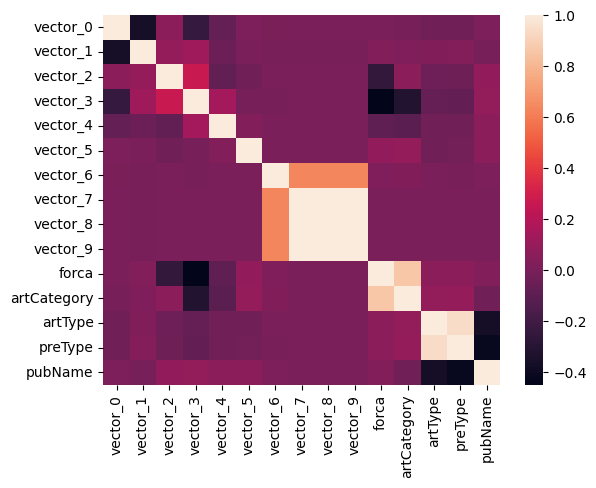

In [99]:
import polars.selectors as cs
from seaborn import heatmap

fig = plt.figure()
heatmap((
    df_vetores
    .with_columns(
        pl.col('artClass').list.to_struct(
            fields=[f'vector_{i}' for i in range(12)]
        )
    )
    .unnest('artClass')
    .join(
        df,
        on='id'
    )
    .with_columns(
        forca=pl.col('artCategory').str.split('/').list.slice(1,1).list.first().map_elements(lambda x: {'Comando da Aeronáutica':0, 'Comando da Marinha':1, 'Comando do Exército':2}[x], return_dtype=pl.Int32).cast(pl.Float64),
        artCategory=pl.col('artCategory').map_elements(lambda x: artCategory_dummy[x], return_dtype=pl.Int32).cast(pl.Float64),
        artType=pl.col('artType').map_elements(lambda x: artType_dummy[x], return_dtype=pl.Int32).cast(pl.Float64),
        pubName=pl.col('pubName').map_elements(lambda x: {'DO1':0, 'DO2':1, 'DO3':2}[x], return_dtype=pl.Int32).cast(pl.Float64),
        preType=pl.col('artType').str.split(' ').list.first().map_elements(lambda x: preType_dummy[x], return_dtype=pl.Int32).cast(pl.Float64)

    )
    .with_columns(
        (cs.float() - cs.float().min()) / (cs.float().max() - cs.float().min())
    )
).select(*[f'vector_{i}' for i in range(10)], 'forca', 'artCategory', 'artType', 'preType', 'pubName').to_pandas().corr())

fig.show()

del fig

Parece que não há nenhuma relação interessante.

As relações óbvias são do `vector_6` com os subsequentes, porque quando o desdobramento hierárquico chega até o nível 7, é muito provável que ele continue, pea contagem que fizemos.

Além disso, as relações entre `forca` e `artCategory`, já que `artCategory` contém a `forca`, `artType`, `preType` e `pubName` também era esperado.

A única relação que chama a atenção é a relação de `vector_3` com `forca`.

In [100]:
(
    df_vetores
    .with_columns(
        pl.col('artClass').list.to_struct(
            fields=[f'vector_{i}' for i in range(12)]
        )
    )
    .unnest('artClass')
    .join(
        df,
        on='id'
    )
    .with_columns(
        (cs.float() - cs.float().min()) / (cs.float().max() - cs.float().min()),
        forca=pl.col('artCategory').str.split('/').list.slice(1,1).list.first().map_elements(lambda x: {'Comando da Aeronáutica':0, 'Comando da Marinha':1, 'Comando do Exército':2}[x], return_dtype=pl.Int32),
        artCategory=pl.col('artCategory').map_elements(lambda x: artCategory_dummy[x], return_dtype=pl.Int32),
        pubName=pl.col('pubName').map_elements(lambda x: {'DO1':0, 'DO2':1, 'DO3':2}[x], return_dtype=pl.Int32)

    )
).group_by('vector_3', 'forca').agg(pl.len()).sort('vector_3')

del artCategory_dummy, artType_dummy, preType_dummy

Não existe uma relação tão significativa, até porque são muito valores diferentes de `vector_3` para apenas 3 `forca`.

Vou tentar mais um vez encontrar esse relacionamento, verificando se esses dados de `artClass` podem ser clusterizados de alguma forma.

In [101]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

df_vetores = df_vetores.with_columns(
    pl.Series(
        'vetor_reduzido',
        pipeline.fit_transform(
            np.vstack(
                df_vetores
                .select('artClass')
                .to_series()
                .to_numpy()
            )
        )
    )
)

del pipeline

In [102]:
df = df.with_columns(
    vetor=df_vetores.select('vetor_reduzido').to_series()
)

del df_vetores

In [103]:
df.head()

id,pubName,pubDate,artCategory,artType,artClass,texto,vetor
str,str,date,str,str,str,str,"array[f64, 2]"
"""530_20231124_21157600""","""DO3""",2023-11-24,"""Ministério da Defesa/Comando d…","""Extrato de Contrato""","""00016:00011:00014:00007:00008:…","""EXTRATO DE CONTRATO Nº 8/2023 …","[-0.007126, 1.432671]"
"""530_20250707_22832429""","""DO3""",2025-07-07,"""Ministério da Defesa/Comando d…","""Retificação""","""00016:00010:00011:00124:00000:…","""RETIFICAÇÃO NO EXTRATO DE TERM…","[-0.007914, 1.239674]"
"""10818815""","""DO3""",2018-06-08,"""Ministério da Defesa/Comando d…","""Aviso de Licitação-Pregão""","""00010:00008:00020:00005:00001:…","""AVISO DE LICITAÇÃO PREGÃO Nº 1…","[-0.016119, -0.448286]"
"""530_20201127_13112893""","""DO3""",2020-11-27,"""Ministério da Defesa/Comando d…","""Extrato de Dispensa de Licitaç…","""00013:00044:00013:00009:00000:…","""EXTRATO DE DISPENSA DE LICITAÇ…","[-0.017306, -0.369285]"
"""530_20200508_12622588""","""DO3""",2020-05-08,"""Ministério da Defesa/Comando d…","""Aviso""","""00011:00045:00008:00045:00006:…","""AVISOCONCORRÊNCIA nº 22/2019 P…","[-0.021782, -0.986346]"


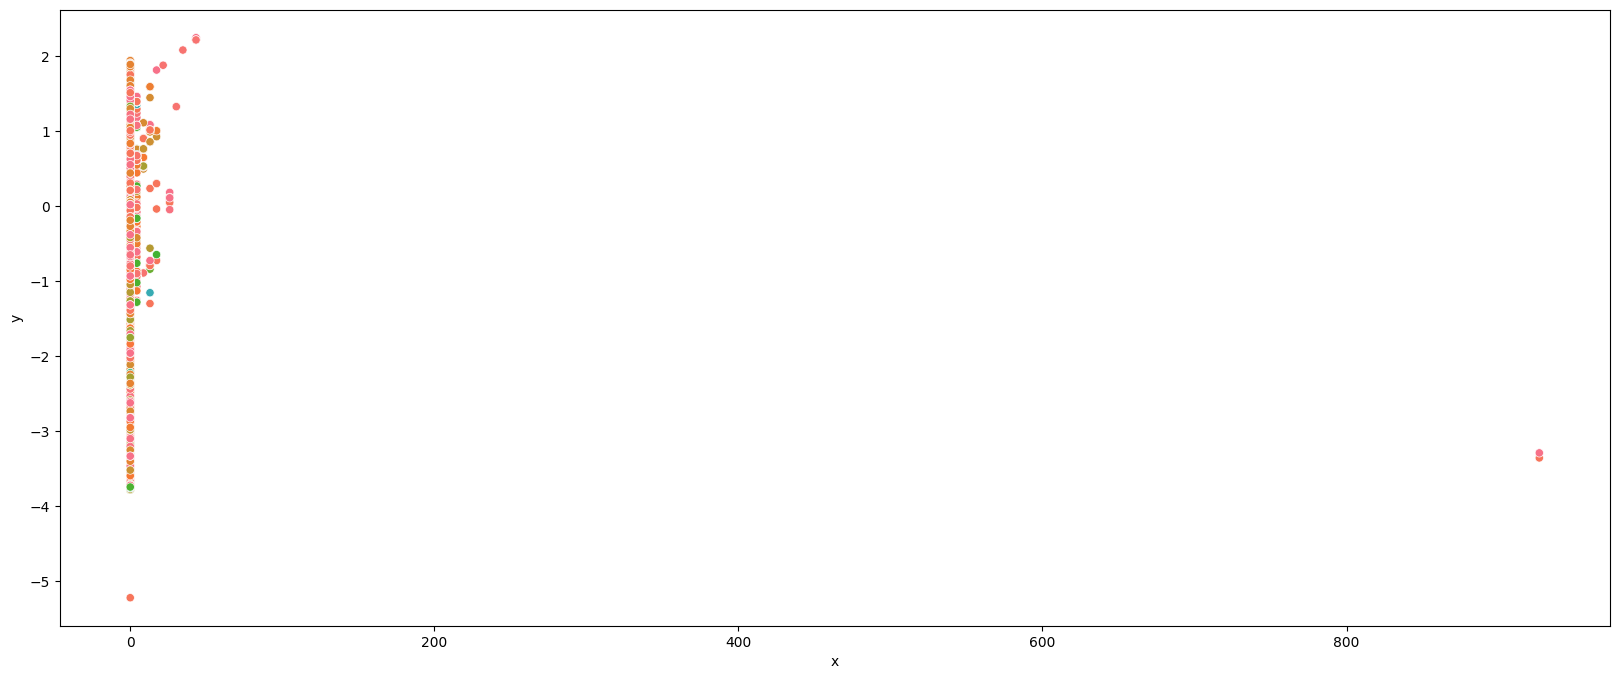

In [104]:
# px.scatter(
#     df.with_columns(
#         x=pl.col('vetor').cast(pl.List).list.first(),
#         y=pl.col('vetor').cast(pl.List).list.last()
#     ).to_pandas(),
#     x='x',
#     y='y',
#     color='artType',
#     hover_name='id'
# )

fig = plt.figure(figsize=(20, 8))
sns.scatterplot(
    data = df.with_columns(
         x=pl.col('vetor').cast(pl.List).list.first(),
         y=pl.col('vetor').cast(pl.List).list.last()
     ).to_pandas(),
    x='x',
    y='y',
    hue='artType',
    legend=False
)

fig.show()

del fig

Os dados de `artClass` realmente não expressam muito.

Vamos voltar atrás e removê-los do dataframe.

In [106]:
df = df.drop('artClass', 'vetor')

df.head()

id,pubName,pubDate,artCategory,artType,texto
str,str,date,str,str,str
"""530_20231124_21157600""","""DO3""",2023-11-24,"""Ministério da Defesa/Comando d…","""Extrato de Contrato""","""EXTRATO DE CONTRATO Nº 8/2023 …"
"""530_20250707_22832429""","""DO3""",2025-07-07,"""Ministério da Defesa/Comando d…","""Retificação""","""RETIFICAÇÃO NO EXTRATO DE TERM…"
"""10818815""","""DO3""",2018-06-08,"""Ministério da Defesa/Comando d…","""Aviso de Licitação-Pregão""","""AVISO DE LICITAÇÃO PREGÃO Nº 1…"
"""530_20201127_13112893""","""DO3""",2020-11-27,"""Ministério da Defesa/Comando d…","""Extrato de Dispensa de Licitaç…","""EXTRATO DE DISPENSA DE LICITAÇ…"
"""530_20200508_12622588""","""DO3""",2020-05-08,"""Ministério da Defesa/Comando d…","""Aviso""","""AVISOCONCORRÊNCIA nº 22/2019 P…"


E quanto ao `texto`, que é a variável mais importante, objeto desta análise?
Pela descrição do dataframe, não existem valores nulos de texto, porém como já vimos na variável `highlight`, é possível que valores nulos estejam passando desapercebidos por serem representados por strings vazias. Vamos verificar se esse é o caso:

In [107]:
(
    df
    .group_by(
        pl.col('texto').str.len_chars().alias('qtd_caracteres')
    )
    .agg(
        pl.len().alias('qtd_textos')
    )
    .sort(
        'qtd_caracteres',
        descending=False
    )
    .show(limit=20)
)

qtd_caracteres,qtd_textos
u32,u32
7,1
14,1
23,3
36,1
43,3
48,4
53,1
58,1
65,1


Não temos nenhum texto vazio, mas temos vários textos menores do que 140 (ao invés de uma publicação no DOU, poderia ser um tweet).

Vejamos se isso faz sentido.

In [108]:
(
    df
    .filter(
        pl.col('texto').str.len_chars() < 140
    )
    .sort(
        pl.col('texto').str.len_chars()
    )
    .show(limit=-1, fmt_str_lengths=140)
)

id,pubName,pubDate,artCategory,artType,texto
str,str,date,str,str,str
"""515_20220425_14448914""","""DO1""",2022-04-25,"""Ministério da Defesa/Comando da Marinha/Empresa Gerencial de Projetos Navais""","""Balanço Patrimonial""","""Balanço"""
"""530_20230102_20222954.xml""","""DO3""",2023-01-02,"""Ministério da Defesa/Comando do Exército/Comando Militar do Oeste/18ª Brigada de Infantaria de Pantanal/2ª Companhia de Fronteira""","""Retificação""","""DE RETIFICACAO"""
"""515_20220217_14273518""","""DO1""",2022-02-17,"""Ministério da Defesa/Comando da Marinha/Comando de Operações Navais/7º Distrito Naval/Capitania Fluvial de Goiás""","""Ato Normativo""","""Anexo A Anexo A ANEXO A"""
"""515_20220217_14273515""","""DO1""",2022-02-17,"""Ministério da Defesa/Comando da Marinha/Comando de Operações Navais/7º Distrito Naval/Capitania Fluvial de Goiás""","""Ato Normativo""","""Anexo C Anexo C ANEXO C"""
"""515_20220217_14273514""","""DO1""",2022-02-17,"""Ministério da Defesa/Comando da Marinha/Comando de Operações Navais/7º Distrito Naval/Capitania Fluvial de Goiás""","""Ato Normativo""","""Anexo B Anexo B ANEXO B"""
"""515_20210305_13334306""","""DO1""",2021-03-05,"""Ministério da Defesa/Comando da Marinha/Empresa Gerencial de Projetos Navais""","""Balanço Patrimonial""","""Empresa Gerencial de Projetos Navais"""
"""530_20230524_20621646.xml""","""DO3""",2023-05-24,"""Ministério da Defesa/Comando do Exército/Comando Militar do Leste/1ª Divisão de Exército/Artilharia Divisionária da 1ª Divisão de Exército/2…","""Extrato de Contrato""","""EXTRATO DE CONTRATO Nº 2/2023 - UASG 160272"""
"""530_20230524_20621662.xml""","""DO3""",2023-05-24,"""Ministério da Defesa/Comando do Exército/Comando Militar do Leste/1ª Divisão de Exército/Artilharia Divisionária da 1ª Divisão de Exército/2…","""Extrato de Contrato""","""EXTRATO DE CONTRATO Nº 2/2023 - UASG 160272"""
"""530_20230524_20621664.xml""","""DO3""",2023-05-24,"""Ministério da Defesa/Comando do Exército/Comando Militar do Leste/1ª Divisão de Exército/Artilharia Divisionária da 1ª Divisão de Exército/2…","""Extrato de Contrato""","""EXTRATO DE CONTRATO Nº 2/2023 - UASG 160272"""


Parece que existe um padrão. Com exceção de alguns erros óbvios, os textos curtos são retificações ou extratos.

In [109]:
(
    df
    .filter(pl.col('texto').str.len_chars() < 140)
    .group_by('pubName', 'artType')
    .agg(
        pl.len().alias('qtd_por_tipo'),
        pl.col('texto').str.len_chars().mean().alias('tamanhoMedio')
    )
    .sort('tamanhoMedio')
)

pubName,artType,qtd_por_tipo,tamanhoMedio
str,str,u32,f64
"""DO1""","""Ato Normativo""",3,23.0
"""DO3""","""Extrato de Contrato""",5,45.0
"""DO3""","""Extrato de Nota de Empenho""",1,53.0
"""DO1""","""Balanço Patrimonial""",5,61.8
"""DO3""","""Extrato de Termo Aditivo""",7,84.285714
"""DO3""","""Extrato de Apostilamento""",208,111.168269
"""DO3""","""Retificação""",12,113.916667
"""DO3""","""Ato""",1,117.0
"""DO3""","""Aviso de Licitação-Leilão""",1,127.0


Aproveitando o ensejo, vamos visualizar como está distribuído o tamanho dos textos pelo tipo de documentos e pelos tipos de publicações.

In [ ]:
tamanho_pd = (
    df.select(
        pl.col("pubName"),
        pl.col("texto").str.len_chars().alias("tamanho")
    )
).to_pandas()

limite_superior = tamanho_pd["tamanho"].quantile(0.95)
plot_data = tamanho_pd[tamanho_pd["tamanho"] <= limite_superior]

# fig = plt.figure(figsize=(12, 6))
# sns.histplot(
#     data=plot_data,
#     x="tamanho",
#     hue="pubName",
#     bins=240,
#     stat="density",
#     common_norm=False,
#     element="step",
#     fill=False,
# )
# plt.title("Distribuicao da contagem de caracteres por seção (até p95)")
# plt.xlabel("Quantidade de caracteres")
# plt.ylabel("Contagem de textos")
# plt.tight_layout()
# fig.show()

fig = plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=plot_data,
    x="tamanho",
    hue="typeRoot",
    common_norm=False,
    fill=False,
    bw_adjust=1,
)

plt.title("Distribuição da contagem de caracteres por seção (até p95)")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Densidade")
plt.tight_layout()
fig.show()

del tamanho_pd, limite_superior, plot_data, fig

In [111]:
(
    df
    .with_columns(
        typeRoot=pl.col("artType").str.split(' ').list.first()
    )
    .group_by('typeRoot')
    .agg(pl.len())
    .filter(pl.col('len') > 0.01*df.height)
    .sort('len', descending=True)
    .show(limit=-1)
)

typeRoot,len
str,u32
"""Extrato""",227149
"""Aviso""",126999
"""Portaria""",88845
"""Resultado""",27823
"""Edital""",15520
"""Retificação""",8990


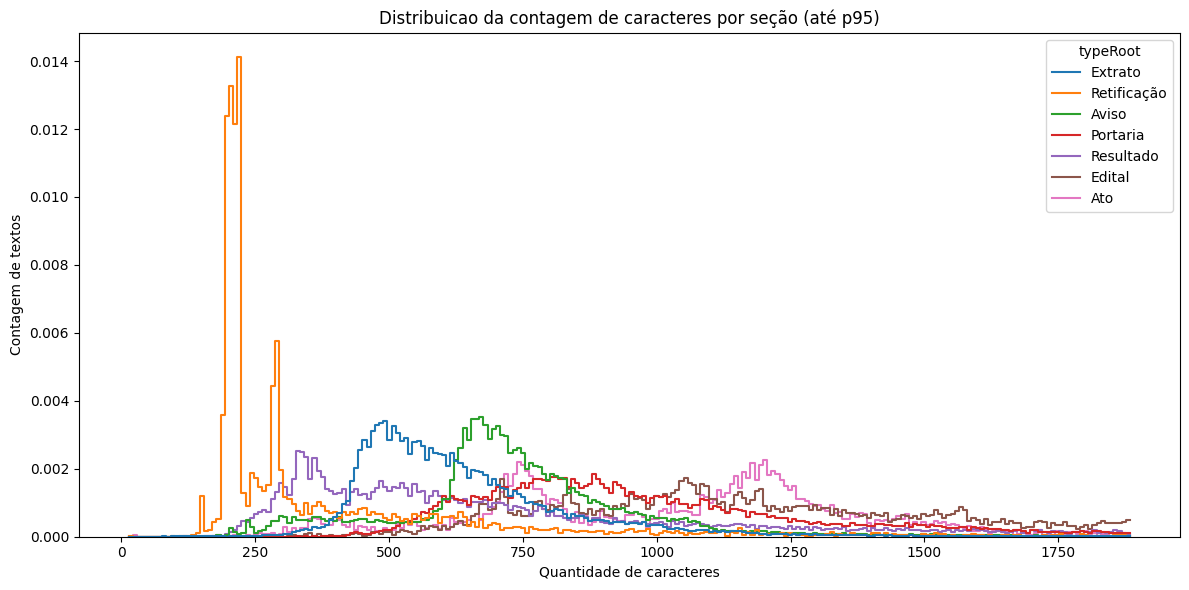

In [112]:
doc_comuns = (
    df
    .with_columns(
        typeRoot=pl.col("artType").str.split(' ').list.first()
    )
    .group_by('typeRoot')
    .agg(pl.len())
    .filter(pl.col('len') > 0.01*df.height)
)

tamanho_pd = (
    df
    .with_columns(
        typeRoot=pl.col("artType").str.split(' ').list.first()
    )
    .filter(
        pl.col('typeRoot').is_in(doc_comuns.select('typeRoot').to_series())
    )
    .select(
        pl.col("typeRoot"),
        pl.col("texto").str.len_chars().alias("tamanho")
    )
).to_pandas()

limite_superior = tamanho_pd["tamanho"].quantile(0.95)
plot_data = tamanho_pd[tamanho_pd["tamanho"] <= limite_superior]

fig = plt.figure(figsize=(12, 6))
sns.histplot(
    data=plot_data,
    x="tamanho",
    hue="typeRoot",
    bins=240,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
)
plt.title("Distribuicao da contagem de caracteres por seção (até p95)")
plt.xlabel("Quantidade de caracteres")
plt.ylabel("Contagem de textos")
plt.tight_layout()
fig.show()

del doc_comuns, tamanho_pd, limite_superior, plot_data, fig

### 2.4.3. Valores duplicados

Verificação para existência de dados duplicados.

In [113]:
df.filter(df.is_duplicated()).shape[0]

0

Não há dados duplicados, mas só pra garantir:

In [114]:
df = df.unique()

## 2.5 Visão Geral da Base de Dados

In [115]:
df.shape

(506666, 6)

In [116]:
df.describe()

statistic,id,pubName,pubDate,artCategory,artType,texto
str,str,str,str,str,str,str
"""count""","""506666""","""506666""","""506666""","""506666""","""506666""","""506666"""
"""null_count""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",null,null,"""2022-02-04 04:05:30.935172""",null,null,null
"""std""",null,null,null,null,null,null
"""min""","""10449257""","""DO1""","""2018-03-12""","""Ministério da Defesa/Comando d…","""Acordo Coletivo de Trabalho""","""""BATALHÃO PERIBEBUÍ"" AVISO DE …"
"""25%""",null,null,"""2020-04-14""",null,null,null
"""50%""",null,null,"""2022-01-18""",null,null,null
"""75%""",null,null,"""2023-11-21""",null,null,null
"""max""","""612_20210401_13401898""","""DO3""","""2026-02-27""","""Ministério da Defesa/Comando d…","""Termo de Autorização""","""PORTARIA Nº 73/AMAZUL, DE 5 …"


# 3. Metodologia

In [117]:
dou2 = df.filter(pl.col('pubName')=='DO2')

In [118]:
dou2.filter(pl.col('texto').str.to_lowercase().str.contains(r'(decide|resolve):?')).group_by('artType').agg(pl.len()).show(fmt_str_lengths=1500)

artType,len
str,u32
"""Ato""",2697
"""Retificação""",35
"""Resolução""",29
"""Despacho""",3
"""Portaria Interministerial""",2


In [119]:
dou2.filter(~pl.col('texto').str.to_lowercase().str.contains(r'(decide|resolve):?')).group_by('artType').agg(pl.len()).show(fmt_str_lengths=1500)

artType,len
str,u32
"""Despacho""",25
"""Retificação""",652
"""Portaria""",571
"""Decisão""",5
"""Ato Concessório""",169


In [120]:
dou2.filter((~pl.col('texto').str.to_lowercase().str.contains(r'(decide|resolve):?')) & (pl.col('artType')=='Portaria')).show(fmt_str_lengths=1500)

id,pubName,pubDate,artCategory,artType,texto
str,str,date,str,str,str
"""529_20230524_20622252.xml""","""DO2""",2023-05-24,"""Ministério da Defesa/Comando do Exército/Departamento de Educação e Cultura do Exército""","""Portaria""","""RETIFICAÇÃO Na Portaria nº 148 - DECEx/C Ex, de 19 de maio de 2023, publicada no Diário Oficial da União nº 97, de 23 de maio de 2023, Seção 2, página 11, referente a nomeação do Coronel da Reserva Remunerada (023134823-6) OSMAR DA SILVA BARROS JUNIOR, PREC CP 96/1665561, no Colégio Militar do Rio de Janeiro (Rio de Janeiro-RJ), para Prestador de Tarefa por Tempo Certo, para exercer a tarefa de Chefe do Escritório de Projetos, pelo prazo de 24 meses, onde se lê "" a partir de 1° de maio de 2023"", leia-se ""a partir de 1° de junho de 2023""."""
"""529_20250326_22516142""","""DO2""",2025-03-26,"""Ministério da Defesa/Comando do Exército/Comando Militar do Leste/1ª Região Militar""","""Portaria""","""PORTARIA nº 5 -SVP/1ª RM/Cmdo 1ª RM, de 25 de MARço de 2025 O COMANDANTE DA 1ª REGIÃO MILITAR, no uso da competência que lhe confere o nº 5, da alínea d) do inciso IX, do art. 1º, da Portaria nº 330 - DGP/DCIPAS, de 7 DEZ 2018, em cumprimento de Decisão Judicial relativa ao Processo nº 0501416-44.2018.4.02.5101, da 6ª Vara Federal do Rio de Janeiro/RJ, com trânsito em julgado em 3 DEZ 24, que determinou a reforma do Autor, com proventos integrais correspondentes ao soldo do grau hierárquico ocupado na ativa, de acordo com o Parecer de Força Executória nº 00374/2024/COREMNG/PRU2R/PGU/AGU, de 11 DEZ 24 e o DIEx nº 1006- Subseção DU/AsseApAsJurd/Cmdo 1ª RM, de 28 JAN 24, proferiu o seguinte despacho: REFORMAR em caráter definitivo com proventos integrais correspondentes ao soldo da graduação de Soldado do Exército, o SD FELIPE DA SILVA CARLOS, Prec/CP 35/2055655, a contar de 29 JUN 18 (data indicada pela Justiça Federal para início da vigência), de acordo com o Parecer de Força Executória nº 00374/2024/COREMNG/PRU2R/PGU/AGU, de 11 DEZ 24 e o DIEx nº 1006 - Subseção DU/AsseApAsJurd/Cmdo 1ª RM, de 28 JAN 24, com fulcro no inciso II do Art. 106 e III do Art.108, da Lei n. 6.880, de 09 DEZ 1980. Gen Div CARLOS DUARTE PONTUAL DE LEMOS"""
"""529_20180627_10866573""","""DO2""",2018-06-27,"""Ministério da Defesa/Comando do Exército/Comando Militar do Leste/1ª Região Militar""","""Portaria""","""PORTARIA Nº 23 GHI SSIM/SAP/1-RIO/SSIP/1, DE 4 DE JUNHO DE 2018 O COMANDANTE DA 1ª REGIÃO MILITAR, no uso da competência que lhe foi conferida pelo inciso III, do art. 7º, da Portaria nº 1.023, do Comandante do Exército, de 10 OUT 13, e com base no processo originário do requerimento datado em 11 JUL 17, onde o 1º Tenente Reformado JOSE AFONSO DA SILVEIRA GOMES, Prec/CP 96/1383223, Idt 047311461-9 MD/EB, CPF 033.332.561-34, solicita o benefício do Grau Hierárquico Imediato (GHI), proferiu o seguinte despacho: (Prot 1082694) Conceder o GHI, no posto de Major, com Adicional Militar de 25% (vinte e cinco por cento), a contar de 18 SET 17, com base no § 1º, do art. 110, da Lei nº 6.880, de 9 DEZ 1980, combinado com o art. 94 do Dec 4.307, de 18 JUL 02 e conforme laudo pericial homologado em 7 MAIO 18, acerca do Parecer Técnico nº 310/18, da Seç Sau Rg/1, de 25 ABR 18. Gen Div FERNANDO JOSE SANT'ANA SOARES E SILVA"""
"""529_20230803_20826971.xml""","""DO2""",2023-08-03,"""Ministério da Defesa/Comando do Exército/Gabinete do Comandante""","""Portaria""","""Retificação Na Portaria do Comandante do Exército nº 961, de 20 de julho de 2023, publicada no Diário Oficial da União nº 138, do dia 20 de julho de 2023, na seção 2, página 7, relativa à nomeação em caráter excepcional do Cel R/1 (0346351729) JOSÉ LINDOLFO WEBER DA SILVA no Colégio Militar de Recife (CMR), em Recife-PE, como Prestador de Tarefa por Tempo Certo, ONDE SE LÊ ""NOMEAR, [...] no Colégio Militar de Recife (CMR), em Recife-PE"", LEIA-SE ""NOMEAR, [...] no Colégio Militar de Salvador (CMS), em Salvador-BA""."""
"""10790668""","""DO2""",2018-05-29,"""Ministério da Def

In [121]:
!spacy download pt_core_news_lg

import nltk
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')

from nltk.corpus import stopwords
pt_stopwords = stopwords.words('portuguese')

nlp = spacy.load('pt_core_news_lg')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 13.4 MB/s  0:00:35
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [122]:
dou2 = (
    dou2
    .with_columns(
        verbos=pl.col('texto').str.to_lowercase().str.extract_all(r'\b[a-zA-Z]+[aeioô]r\b').list.unique()
    )
)

verb_corpus = dou2.select('verbos').to_series().to_list()

verb_set = set(np.hstack(dou2.select('verbos').to_series()).tolist())
verb_set = [i for i in verb_set if nlp(i)[0].pos_ == 'VERB']

verb_corpus = [[i for i in j if i in verb_set] for j in verb_corpus]

verb_corpus = [' '.join(i) for i in verb_corpus]

In [123]:
vectorizer = TfidfVectorizer(stop_words=pt_stopwords)

tfidf_matrix = vectorizer.fit_transform(verb_corpus)

In [124]:
pl.DataFrame(
    tfidf_matrix.toarray(),
    schema=vectorizer.get_feature_names_out().tolist(),
    orient='row'
)

abarrancar,abastecer,abgar,abimar,abinader,abnader,abner,absair,abster,acar,acatar,aceitar,acemar,achcar,acolher,acompanhar,acrescentar,acridomar,acumular,adair,adalcimar,adejair,adelar,adelimar,adentrar,adequar,adevir,adhemar,adiar,adidefnavaerequador,adilar,adimar,adir,adjudicar,admar,administrar,admitir,…,wester,westminster,weuler,wieser,wildberger,wilder,wildnner,wildver,wiler,wilmar,wittemar,wizintener,wortmeyer,xerter,yasser,ygor,yusser,zajdsznajder,zalderir,zalmir,zamuner,zarzar,zelar,zemar,zenir,zenor,ziegler,zilamar,zimerer,zipperer,zohler,zolemar,zolnir,zomar,zuelber,zulmar,zweibrucker
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [125]:
print("Vocabulary without stopwords:", vectorizer.get_feature_names_out())
print("Matrix shape:", tfidf_matrix.shape)

Vocabulary without stopwords: ['abarrancar' 'abastecer' 'abgar' ... 'zuelber' 'zulmar' 'zweibrucker']
Matrix shape: (91050, 1522)


In [126]:
# lista_verbos = list(map(str.lower, np.hstack(dou2.with_columns(
#     verbos=pl.col('texto').str.extract_all(r'\b[a-zA-Z]+[aeioô]r\b')
# ).select('verbos').to_series().to_numpy())))

In [127]:
# dict_verbos = {i:lista_verbos.count(i) for i in set(lista_verbos)}

In [128]:
# (pl.from_dict(dict_verbos)
# .drop('por', 'partir', 'militar', 'contar', 'prestador', 'vigor', 'ter', 'ser', 'complementar', 'auxiliar', 'maior', 'diretor', 'parecer', 'valor', 'major', 'salvador', 'instrutor', 'coordenador', 'aviador', 'carater', 'professor', 'servidor', 'assessor')
# .transpose(include_header=True).sort('column_0', descending=True))

In [129]:
# (
#     dou2
#     .with_columns(
#         nomeacao=(pl.col('texto').str.to_lowercase().str.contains(r'nomear')),
#         exoneracao=(pl.col('texto').str.to_lowercase().str.contains('exonerar')),
#         concessao=(pl.col('texto').str.to_lowercase().str.contains('conceder')),
#         promocao=(pl.col('texto').str.to_lowercase().str.contains('promover')),
#         prorrogacao=(pl.col('texto').str.to_lowercase().str.contains('prorrogar')),
#         colocacao=(pl.col('texto').str.to_lowercase().str.contains(r'colocar(.+)disposição')),
#         designacao=(pl.col('texto').str.to_lowercase().str.contains('designar')),
#         manutencao=(pl.col('texto').str.to_lowercase().str.contains('manter')),
#         aposentadoria=(pl.col('texto').str.to_lowercase().str.contains('aposentar')),
#         demissao=(pl.col('texto').str.to_lowercase().str.contains('demitir')),
#         contratacao=(pl.col('texto').str.to_lowercase().str.contains('contratar')),
#         reversao=(pl.col('texto').str.to_lowercase().str.contains('reverter')),
#         alteracao=(pl.col('texto').str.to_lowercase().str.contains('alterar')),
#         transferencia=(pl.col('texto').str.to_lowercase().str.contains('transferir')),
#         renovacao=(pl.col('texto').str.to_lowercase().str.contains(r'renovar')),
#         reforma=(pl.col('texto').str.to_lowercase().str.contains(r'reformar')),
#         garantia=(pl.col('texto').str.to_lowercase().str.contains(r'assegurar')),
#         dispensa=(pl.col('texto').str.to_lowercase().str.contains(r'dispensar')),
#         cancelamento=(pl.col('texto').str.to_lowercase().str.contains(r'cancelar')),
#         sem_efeito=(pl.col('texto').str.to_lowercase().str.contains(r'tornar sem efeito')),
#         anulacao=(pl.col('texto').str.to_lowercase().str.contains(r'anular')),
#         consideracao=(pl.col('texto').str.to_lowercase().str.contains(r'considerar')),
#         agregacao=(pl.col('texto').str.to_lowercase().str.contains(r'agregar')),
#         licenciamento=(pl.col('texto').str.to_lowercase().str.contains(r'licenciar')),
#         inclusao=(pl.col('texto').str.to_lowercase().str.contains(r'incluir')),
#         incorporacao=(pl.col('texto').str.to_lowercase().str.contains(r'incorporar')),
#         declaracao=(pl.col('texto').str.to_lowercase().str.contains(r'declarar')),
#         revogacao=(pl.col('texto').str.to_lowercase().str.contains(r'revogar')),
#         exclusao=(pl.col('texto').str.to_lowercase().str.contains(r'excluir')),
#         autorizacao=(pl.col('texto').str.to_lowercase().str.contains(r'autorizar')),
#         convocacao=(pl.col('texto').str.to_lowercase().str.contains(r'convocar')),
#         tornar_insub=(pl.col('texto').str.to_lowercase().str.contains(r'tornar insubsistente')),
#         suspencao=(pl.col('texto').str.to_lowercase().str.contains(r'suspender')),
#         reestabelecimento=(pl.col('texto').str.to_lowercase().str.contains(r'ree?stabelecer')),
#         cassacao=(pl.col('texto').str.to_lowercase().str.contains(r'cassar')),
#         dispor=(pl.col('texto').str.to_lowercase().str.contains(r'passar [àa] disposição')),
#     )
# ).filter(
#     ~pl.any_horizontal(cs.boolean()) & ~pl.col('texto').str.to_lowercase().str.contains('onde se lê')).select('texto').show(fmt_str_lengths=1500)

## 3.1. Identificação das publicações por Força

## 3.2. Padronização

## 3.3. Classificação temática

## 3.4. Critérios de análise

# 4. Análise Exploratória Inicial

## 4.1. Volume total

## 4.2. Distribuição temporal

## 4.3. Distribuição por Força

# 5. Análise Temática

## 5.1. Categorias

## 5.2. Frequência por categoria

## 5.3. Comparação entre Forças

## 5.4. Evolução temporal

# 6. Indicadores e Perfis Institucionais

## 6.1. Indicadores por dimensão

## 6.2. Interpretação comparativa

## 6.3. Síntese dos perfis

# 7. Conclusão

## 7.1. Principais achados

## 7.2. Limitações

## 7.3. Trabalhos futuros